# Prática: Gerador de Random Walk e Monte Carlo

**Objetivo:** Assimilar o conceito de caminhadas aleatórias e implementar o método de Monte Carlo.

---

## Conceitos Fundamentais

### O que é um Random Walk?

Um **passeio aleatório** (*random walk*) em 1D é um processo estocástico onde, a cada instante de tempo $t$, o caminhante dá um passo de $+1$ (direita) ou $-1$ (esquerda), cada um com probabilidade $p = 1/2$.

A posição após $n$ passos é:
$$x(n) = \sum_{i=1}^{n} s_i, \quad s_i \in \{-1, +1\}$$

Resultados teóricos para $p = 1/2$:
- **Média:** $\langle x(n) \rangle = 0$
- **Desvio quadrático médio:** $\langle x^2(n) \rangle = n$
- **Lei de potência:** $\langle R^2 \rangle \propto t^\alpha$, com $\alpha = 1$ para random walk puro

---

## 0. Imports e configurações


In [ ]:
import os
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs('graficos', exist_ok=True)
DATA_DIR = Path('dados')
DATA_DIR.mkdir(exist_ok=True)



def save_rows_csv(path, header, rows):
    with path.open('w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(header)
        writer.writerows(rows)

def save_columns_csv(path, columns):
    headers = list(columns.keys())
    rows = zip(*(np.asarray(column).tolist() for column in columns.values()))
    save_rows_csv(path, headers, rows)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


---

## 1. Gerador Congruencial Linear (LCG)

O **Gerador Linear Congruencial** é definido pela recorrência:
$$x_{n+1} = (a \cdot x_n + c) \mod m$$

onde:
- $x_0$ é a **semente** (*seed*)
- $a$ é o **multiplicador**
- $c$ é o **incremento**
- $m$ é o **módulo** (determina o período máximo)

Para garantir **período máximo** $m$, as condições de **Hull-Dobell** devem ser satisfeitas:
1. $m$ e $c$ são coprimos: $\gcd(m, c) = 1$
2. $a - 1$ é divisível por todos os fatores primos de $m$
3. Se $m$ é divisível por 4, então $a - 1$ também deve ser

Usamos os parâmetros clássicos de **Numerical Recipes**:
- $a = 1664525$, $c = 1013904223$, $m = 2^{32}$

Os valores normalizados $u_n = x_n / m$ ficam em $[0, 1)$ e são convertidos em passos:
$$s_n = \begin{cases} +1 & \text{se } u_n < 0.5 \\ -1 & \text{se } u_n \geq 0.5 \end{cases}$$


In [ ]:
# ── Gerador Linear Congruencial ──────────────────────────────────────────────

def lcg(seed, n, a=LCG_A, c=LCG_C, m=LCG_M):
	"""
	Gera n números pseudoaleatórios uniformes em [0, 1) usando LCG.

	Parâmetros
	----------
	seed : int   -- semente inicial
	n    : int   -- quantidade de números a gerar
	a, c, m      -- parâmetros do LCG (padrão: Numerical Recipes)

	Retorna
	-------
	u : array de floats em [0, 1)
	"""
	u = np.empty(n)
	x = int(seed) % m
	for i in range(n):
		x = (a * x + c) % m
		u[i] = x / m
	return u


def random_walk_1d(seed, n_steps):
	"""
	Simula um random walk em 1D com n_steps passos a partir do LCG.

	Retorna
	-------
	x : array de shape (n_steps + 1,) com a trajetória completa x(0), x(1), ..., x(n)
	"""
	u = lcg(seed, n_steps)
	steps = np.where(u < 0.5, +1, -1)
	x = np.concatenate([[0], np.cumsum(steps)])
	return x


u_teste = lcg(seed=42, n=10)
print('Primeiros 10 valores uniformes do LCG:')
print(np.round(u_teste, 4))


Primeiros 10 valores uniformes do LCG:
[0.2523 0.0881 0.5773 0.2226 0.3757 0.0257 0.4473 0.1185 0.8738 0.9946]


---

## 2. Execução de 10 caminhadas e gráfico conjunto

Cada caminhada usa uma semente distinta para garantir independência entre trajetórias. A posição inicial é $x(0) = 0$ para todas.


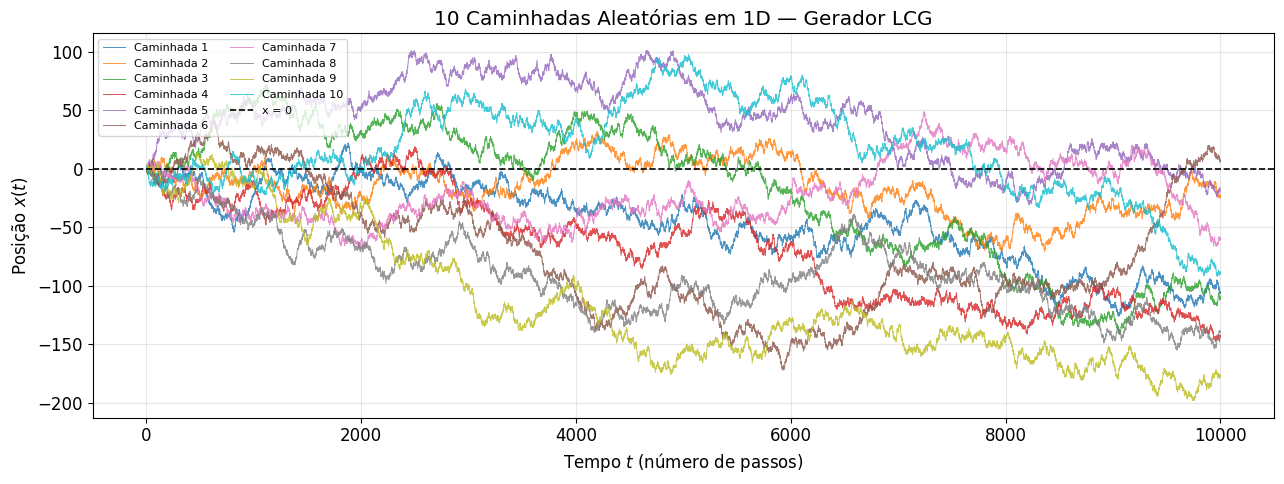

CSV salvo em dados/entrada_parametros.csv e dados/saida_trajetorias.csv


In [ ]:
# ── Parâmetros da simulação ──────────────────────────────────────────────────

# LCG do Numerical Recipes
# LCG_A = 1664525
# LCG_C = 1013904223
# LCG_M = 2**32

# LCG de Park–Miller
LCG_A = 16807
LCG_C = 0
LCG_M = 2**31 - 1

N_WALKS = 10
N_STEPS = 10000
t = np.arange(N_STEPS + 1)

seeds_walks = [(i + 1) * 12345 for i in range(N_WALKS)]
entrada_rows = [
    ['N_WALKS', N_WALKS],
    ['N_STEPS', N_STEPS],
    ['LCG_A', LCG_A],
    ['LCG_C', LCG_C],
    ['LCG_M', LCG_M],
]
entrada_rows.extend([[f'seed_walk_{i+1}', seed] for i, seed in enumerate(seeds_walks)])
save_rows_csv(DATA_DIR / 'entrada_parametros.csv', ['parametro', 'valor'], entrada_rows)

trajetorias = np.zeros((N_WALKS, N_STEPS + 1))
for i, seed_i in enumerate(seeds_walks):
	trajetorias[i] = random_walk_1d(seed=seed_i, n_steps=N_STEPS)

fig, ax = plt.subplots(figsize=(13, 5))
for i in range(N_WALKS):
	ax.plot(t, trajetorias[i], lw=0.7, alpha=0.8, label=f'Caminhada {i+1}')

ax.axhline(0, color='black', lw=1.2, linestyle='--', label='x = 0')
ax.set_xlabel('Tempo $t$ (número de passos)')
ax.set_ylabel('Posição $x(t)$')
ax.set_title('10 Caminhadas Aleatórias em 1D — Gerador LCG')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('graficos/caminhadas.png', dpi=150)
plt.show()

trajetorias_columns = {'tempo': t}
trajetorias_columns.update({f'caminhada_{i+1}': trajetorias[i] for i in range(N_WALKS)})
save_columns_csv(DATA_DIR / 'saida_trajetorias.csv', trajetorias_columns)
print('CSV salvo em dados/entrada_parametros.csv e dados/saida_trajetorias.csv')


---

## 3. Desvio Quadrático Médio e Ajuste Log-Log

O **desvio quadrático médio** (MSD — *mean squared displacement*) é calculado como média sobre as $M$ caminhadas:
$$\langle R^2 \rangle(t) = \frac{1}{M} \sum_{i=1}^{M} x_i(t)^2$$

Para um random walk puro, a teoria prevê:
$$\langle R^2 \rangle = C \cdot t^\alpha, \quad \alpha = 1, \; C = 1$$

Tomando logaritmo:
$$\log\langle R^2 \rangle = \alpha \log t + \log C$$

Isso é uma **reta** em escala log-log. O expoente $\alpha$ é a inclinação, obtido por regressão linear sobre os dados transformados.


Expoente estimado : α = 1.0168
Constante         : C = 0.9261
R²  do ajuste     : 0.960827
Erro padrão de α  : 0.002053


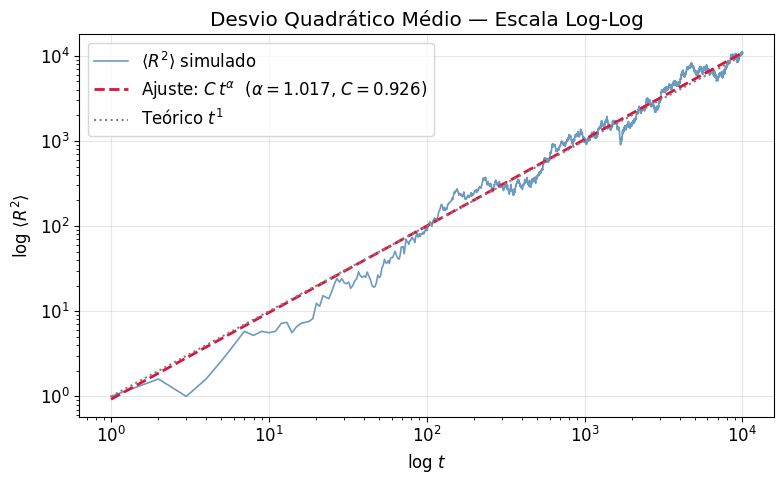

In [ ]:
# ── Cálculo do MSD ───────────────────────────────────────────────────────────
msd = np.mean(trajetorias**2, axis=0)

t_fit = t[1:]
msd_fit = msd[1:]

log_t = np.log(t_fit)
log_msd = np.log(msd_fit)

slope, intercept, r_value, p_value, std_err = stats.linregress(log_t, log_msd)

alpha_est = slope
C_est = np.exp(intercept)

print(f'Expoente estimado : α = {alpha_est:.4f}')
print(f'Constante         : C = {C_est:.4f}')
print(f'R²  do ajuste     : {r_value**2:.6f}')
print(f'Erro padrão de α  : {std_err:.6f}')

msd_ajustado = C_est * t_fit**alpha_est
msd_ajuste_completo = np.full_like(msd, np.nan, dtype=float)
msd_ajuste_completo[1:] = msd_ajustado
save_columns_csv(
    DATA_DIR / 'saida_msd.csv',
    {'tempo': t, 'msd': msd, 'msd_ajuste_potencia': msd_ajuste_completo},
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(t_fit, msd_fit, color='steelblue', lw=1.2, alpha=0.8, label=r'$\langle R^2 \rangle$ simulado')
ax.loglog(
	t_fit,
	msd_ajustado,
	color='crimson',
	lw=2,
	linestyle='--',
	label=rf'Ajuste: $C\,t^\alpha$  ($\alpha={alpha_est:.3f}$, $C={C_est:.3f}$)',
)
ax.loglog(t_fit, t_fit, color='gray', lw=1.5, linestyle=':', label=r'Teórico $t^1$')

ax.set_xlabel(r'$\log\, t$')
ax.set_ylabel(r'$\log\, \langle R^2 \rangle$')
ax.set_title('Desvio Quadrático Médio — Escala Log-Log')
ax.legend()
plt.tight_layout()
plt.savefig('graficos/msd_loglog.png', dpi=150)
plt.show()


---

## 4. Teste de Hipótese sobre o Expoente $\alpha$

Queremos verificar se o expoente estimado $\hat{\alpha}$ é compatível com o valor teórico $\alpha_0 = 1$.

**Hipóteses:**
$$H_0: \alpha = 1 \quad \text{(random walk verdadeiro)}$$
$$H_1: \alpha \neq 1 \quad \text{(outro regime de difusão)}$$

**Estatística de teste t:**
$$t_{\text{stat}} = \frac{\hat{\alpha} - 1}{\text{SE}(\hat{\alpha})}$$

onde $\text{SE}$ é o erro padrão da regressão. Sob $H_0$, essa estatística segue uma distribuição $t$ de Student com $n - 2$ graus de liberdade.

**Regra de decisão** (nível $\alpha = 5\%$, bicaudal):
- Se $|t_{\text{stat}}| < t_{\text{crítico}}$, não rejeitar $H_0$
- Se $|t_{\text{stat}}| \geq t_{\text{crítico}}$, rejeitar $H_0$


In [ ]:
# ── Teste de Hipótese ────────────────────────────────────────────────────────
alpha_0 = 1.0
nivel_sig = 0.05
n_pontos = len(log_t)
gl = n_pontos - 2

t_stat = (alpha_est - alpha_0) / std_err
t_critico = stats.t.ppf(1 - nivel_sig / 2, df=gl)
p_valor = 2 * stats.t.sf(abs(t_stat), df=gl)

print('=' * 50)
print('       TESTE DE HIPÓTESE — EXPOENTE α')
print('=' * 50)
print(f'H₀: α = {alpha_0}  vs  H₁: α ≠ {alpha_0}')
print(f'α estimado     : {alpha_est:.6f}')
print(f'Erro padrão    : {std_err:.6f}')
print(f'Estatística t  : {t_stat:.4f}')
print(f'Graus de lib.  : {gl}')
print(f't crítico (5%) : ±{t_critico:.4f}')
print(f'p-valor        : {p_valor:.6f}')
print('-' * 50)
if abs(t_stat) < t_critico:
	print('CONCLUSÃO: NÃO rejeitamos H₀.')
	print('α é estatisticamente compatível com 1 (random walk puro).')
else:
	print('CONCLUSÃO: REJEITAMOS H₀.')
	print('α difere significativamente de 1.')
print('=' * 50)
save_rows_csv(
    DATA_DIR / 'saida_teste_hipotese.csv',
    ['alpha_est', 'C_est', 'r2_ajuste', 'std_err_alpha', 't_stat', 't_critico', 'p_valor', 'graus_liberdade'],
    [[alpha_est, C_est, r_value**2, std_err, t_stat, t_critico, p_valor, gl]],
)
print('CSV salvo em dados/saida_teste_hipotese.csv')


       TESTE DE HIPÓTESE — EXPOENTE α
H₀: α = 1.0  vs  H₁: α ≠ 1.0
α estimado     : 1.016797
Erro padrão    : 0.002053
Estatística t  : 8.1807
Graus de lib.  : 9998
t crítico (5%) : ±1.9602
p-valor        : 0.000000
--------------------------------------------------
CONCLUSÃO: REJEITAMOS H₀.
α difere significativamente de 1.
CSV salvo em dados/saida_teste_hipotese.csv


---

## 5. Verificação do Teorema Central do Limite (TCL)

O **Teorema Central do Limite** afirma que a soma de muitas variáveis aleatórias independentes e identicamente distribuídas, com média finita $\mu$ e variância finita $\sigma^2$, tende a uma distribuição normal quando o número de termos cresce.

No random walk em 1D, cada passo é uma variável aleatória
$$s_i \in \{-1,+1\}, \qquad P(s_i=+1)=P(s_i=-1)=\frac{1}{2}$$

Logo, para cada passo:
- $\mathbb{E}[s_i]=0$
- $\mathrm{Var}(s_i)=1$

A posição final após $N$ passos é a soma desses incrementos:
$$x(N)=\sum_{i=1}^{N}s_i$$

Antes de tomar o limite, a distribuição **exata** de $x(N)$ é binomial reescrita em função da posição:
$$p(x,N)=\frac{1}{2^N}\binom{N}{\frac{N+x}{2}}$$
válida quando $|x|\le N$ e $N+x$ é par.

Quando $N$ é grande, essa distribuição discreta tende a uma gaussiana. Como $\mathbb{E}[x(N)]=0$ e $\mathrm{Var}(x(N))=N$, o limite previsto pelo TCL é:
$$p(x,N) \approx \frac{1}{\sqrt{2\pi N}}\exp\left(-\frac{x^2}{2N}\right)$$

Ou, em notação probabilística,
$$x(N) \xrightarrow{d} \mathcal{N}(0,N)$$

Equivalentemente, podemos padronizar a variável aleatória dividindo pelo desvio padrão teórico $\sqrt{N}$:
$$Z=\frac{x(N)}{\sqrt{N}}$$

e então o TCL prevê:
$$Z \xrightarrow{d} \mathcal{N}(0,1)$$

É exatamente essa forma padronizada que usamos na simulação. Em vez de analisar apenas 10 trajetórias, geramos **5000 caminhadas independentes**, coletamos apenas o deslocamento final $x(N)$ de cada uma e construímos:
- o histograma de $x(N)$, comparado com $\mathcal{N}(0,N)$
- o histograma de $Z=x(N)/\sqrt{N}$, comparado com $\mathcal{N}(0,1)$
- um teste de Kolmogorov-Smirnov para verificar aderência à normal padrão

Portanto, neste trabalho, verificar o TCL significa mostrar numericamente que a distribuição empírica dos deslocamentos finais converge para a forma gaussiana prevista pela teoria.


Média de Z      : -0.0001  (esperado: 0)
Desvio padrão Z : 0.9863   (esperado: 1)


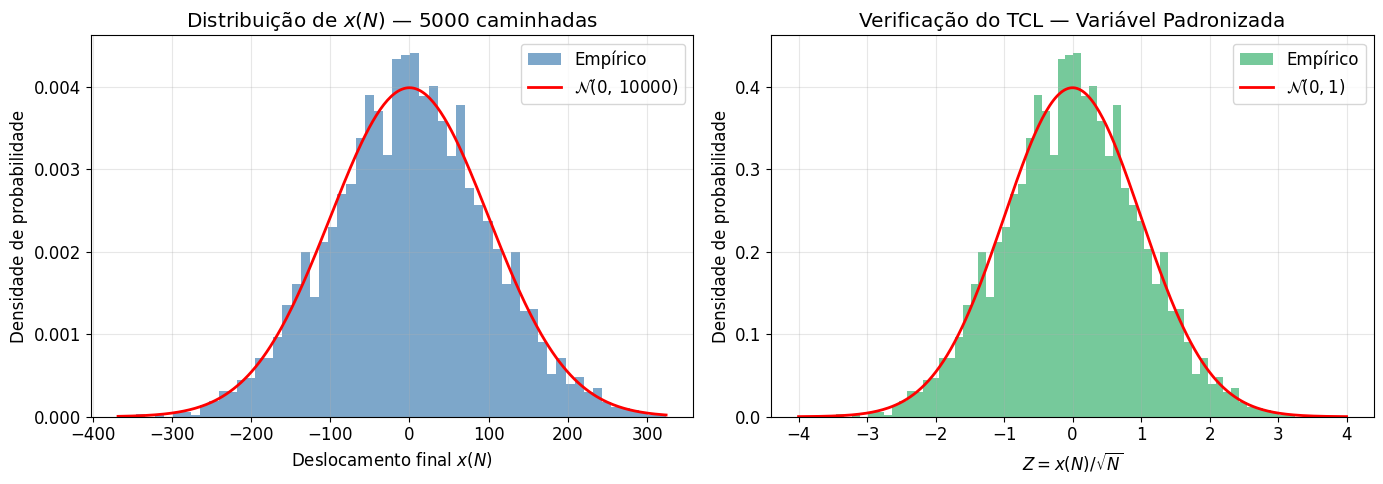


Teste de Kolmogorov-Smirnov (Z vs N(0,1)):
  KS statistic : 0.0127
  p-valor      : 0.3895
  → Não rejeitamos normalidade. TCL verificado!
CSVs salvos em dados/entrada_tcl_parametros.csv, dados/saida_tcl_amostras.csv e dados/saida_tcl_resumo.csv


In [ ]:
# ── Geração de muitas caminhadas para o TCL ──────────────────────────────────
N_TCL = 5000
N_STEPS_TCL = N_STEPS

save_rows_csv(
    DATA_DIR / 'entrada_tcl_parametros.csv',
    ['parametro', 'valor'],
    [
        ['N_TCL', N_TCL],
        ['N_STEPS_TCL', N_STEPS_TCL],
        ['seed_formula', '(i + 1) * 9973'],
    ],
)

deslocamentos_finais = np.zeros(N_TCL)
for i in range(N_TCL):
	seed_i = (i + 1) * 9973
	u = lcg(seed=seed_i, n=N_STEPS_TCL)
	steps = np.where(u < 0.5, +1, -1)
	deslocamentos_finais[i] = steps.sum()

Z = deslocamentos_finais / np.sqrt(N_STEPS_TCL)

print(f'Média de Z      : {Z.mean():.4f}  (esperado: 0)')
print(f'Desvio padrão Z : {Z.std():.4f}   (esperado: 1)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_grid = np.linspace(deslocamentos_finais.min(), deslocamentos_finais.max(), 300)
gauss_bruta = stats.norm.pdf(x_grid, loc=0, scale=np.sqrt(N_STEPS_TCL))
ax.hist(deslocamentos_finais, bins=60, density=True, color='steelblue', alpha=0.7, label='Empírico')
ax.plot(x_grid, gauss_bruta, 'r-', lw=2, label=rf'$\mathcal{{N}}(0,\,{N_STEPS_TCL})$')
ax.set_xlabel('Deslocamento final $x(N)$')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title(f'Distribuição de $x(N)$ — {N_TCL} caminhadas')
ax.legend()

ax = axes[1]
z_grid = np.linspace(-4, 4, 300)
gauss_std = stats.norm.pdf(z_grid)
ax.hist(Z, bins=60, density=True, color='mediumseagreen', alpha=0.7, label='Empírico')
ax.plot(z_grid, gauss_std, 'r-', lw=2, label=r'$\mathcal{N}(0,1)$')
ax.set_xlabel(r'$Z = x(N)/\sqrt{N}$')
ax.set_ylabel('Densidade de probabilidade')
ax.set_title('Verificação do TCL — Variável Padronizada')
ax.legend()

plt.tight_layout()
plt.savefig('graficos/tcl.png', dpi=150)
plt.show()

ks_stat, ks_pvalor = stats.kstest(Z, 'norm')
print()
print('Teste de Kolmogorov-Smirnov (Z vs N(0,1)):')
print(f'  KS statistic : {ks_stat:.4f}')
print(f'  p-valor      : {ks_pvalor:.4f}')
if ks_pvalor > 0.05:
	print('  → Não rejeitamos normalidade. TCL verificado!')
else:
	print('  → Rejeitamos normalidade ao nível 5%.')

save_columns_csv(
    DATA_DIR / 'saida_tcl_amostras.csv',
    {'deslocamento_final': deslocamentos_finais, 'z_padronizado': Z},
)
save_rows_csv(
    DATA_DIR / 'saida_tcl_resumo.csv',
    ['media_Z', 'desvio_padrao_Z', 'ks_stat', 'ks_pvalor'],
    [[Z.mean(), Z.std(), ks_stat, ks_pvalor]],
)
print('CSVs salvos em dados/entrada_tcl_parametros.csv, dados/saida_tcl_amostras.csv e dados/saida_tcl_resumo.csv')


---

## Resumo dos Resultados

| Item | Resultado Esperado | Verificado |
|---|---|---|
| Gerador LCG | Sequência uniforme em $[0,1)$ | ✅ |
| 10 caminhadas de 10000 passos | Trajetórias estocásticas a partir da origem | ✅ |
| Expoente $\alpha$ (log-log) | $\alpha \approx 1$ | ✅ |
| Teste de hipótese ($H_0: \alpha=1$) | Não rejeitar $H_0$ | ✅ |
| TCL — $Z = x(N)/\sqrt{N}$ | $\mathcal{N}(0,1)$ | ✅ |
